# Pertemuan 04 — Hands-on 02: LeNet-5 from Scratch Menggunakan PyTorch
**Mata Kuliah:** Deep Learning (IF25-40401) — Program Studi Teknik Informatika, Institut Teknologi Sumatera (ITERA)  
**Materi:** Membangun, Melatih, dan Mengevaluasi Arsitektur LeNet-5 Klasik (Yann LeCun, 1998) pada Dataset MNIST  
**Alokasi Waktu:** ~60 Menit (Tatap Muka Kelas TM 3×50′)  
**Pemetaan Slide:** Bagian 05 (*Slide Frame 50–71*, `materials/pertemuan-04-cnn-from-scratch.tex`)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/informatika-itera/deep-learning-IF25-40401/blob/main/materials/notebooks/02-lenet5-pytorch.ipynb)

---

### Capaian Pembelajaran (Sub-CPMK)
1. **Sub-CPMK 3:** Membangun arsitektur CNN klasik LeNet-5 dari awal menggunakan modul `torch.nn.Module` dan `nn.Sequential`.
2. **Sub-CPMK 2:** Menelusuri rantai perubahan resolusi spasial tensor (*forward shape progression*) dan memvalidasi hitungan parameter terhadap formula analitis.
3. **Sub-CPMK 3:** Menerapkan alur 5 langkah baku *training loop* PyTorch (`zero_grad`, `forward`, `loss`, `backward`, `step`) serta mode evaluasi (`eval`, `torch.no_grad`).
4. **Sub-CPMK 4:** Menganalisis konsentrasi bobot parameter pada Fully Connected layers vs Convolutional layers.

---

### Prasyarat Pustaka (Slide Frame 59)
```bash
pip install torch torchvision torchinfo matplotlib
```

In [1]:
# Instalasi torchinfo (silent mode)
# %pip install torchinfo -q

import os
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms
from torchinfo import summary

# Pengaturan seed untuk hasil eksperimen yang konsisten dan deterministik
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Deteksi perangkat komputasi terakselerasi (CUDA -> Apple Silicon MPS -> CPU)
device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))

print("=" * 65)
print(f"PyTorch Version       : {torch.__version__}")
print(f"Torchvision Version   : {torchvision.__version__}")
print(f"Perangkat Komputasi   : {device}")
print("=" * 65)

PyTorch Version       : 2.14.0
Torchvision Version   : 0.29.0
Perangkat Komputasi   : mps


## 1. Persiapan Dataset MNIST

Dataset MNIST terdiri dari 70.000 citra tulisan tangan digit 0–9 (60.000 data latih dan 10.000 data uji).

> **Catatan Historis Dimensi Input (LeNet-5 1998):**  
> Citra asli MNIST berukuran $28 \times 28$ piksel. Namun, arsitektur asli LeNet-5 yang diperkenalkan Yann LeCun (1998) didesain untuk input berukuran **$32 \times 32$ piksel** (dengan menambahkan padding 2 piksel di sekeliling citra atau *resize* ke 32×32).  
> Ini memastikan informasi goresan digit di tepian tidak hilang dan menghasilkan *feature map* konvolusi pertama ($C_1$) yang simetris berukuran $28 \times 28$.

In [2]:
# Pipeline transformasi citra: Resize ke 32x32, Ubah ke Tensor, Normalisasi
# Nilai mean 0.1307 dan std 0.3081 adalah statistik global standar dataset MNIST
transformasi_mnist = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Direktori penyimpanan lokal dataset
DIR_DATA = "./data"
os.makedirs(DIR_DATA, exist_ok=True)

# Muat data latih dan data uji
print("Memuat dataset MNIST (mengunduh otomatis jika belum ada di lokal)...")
try:
    train_dataset = datasets.MNIST(root=DIR_DATA, train=True, download=True, transform=transformasi_mnist)
    test_dataset = datasets.MNIST(root=DIR_DATA, train=False, download=True, transform=transformasi_mnist)
    dataset_name = "MNIST"
except Exception as e:
    print(f"[Peringatan Mirror] Unduhan MNIST terkendala ({e}). Beralih ke FashionMNIST...")
    train_dataset = datasets.FashionMNIST(root=DIR_DATA, train=True, download=True, transform=transformasi_mnist)
    test_dataset = datasets.FashionMNIST(root=DIR_DATA, train=False, download=True, transform=transformasi_mnist)
    dataset_name = "FashionMNIST (Fallback)"

# DataLoader mini-batch
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

print(f"✓ Dataset {dataset_name} berhasil dimuat!")
print(f"  Jumlah Sampel Latih : {len(train_dataset):,} citra")
print(f"  Jumlah Sampel Uji   : {len(test_dataset):,} citra")
print(f"  Bentuk Tensor Citra : {train_dataset[0][0].shape} (Channels=1, H=32, W=32)")

Memuat dataset MNIST (mengunduh otomatis jika belum ada di lokal)...
✓ Dataset MNIST berhasil dimuat!
  Jumlah Sampel Latih : 60,000 citra
  Jumlah Sampel Uji   : 10,000 citra
  Bentuk Tensor Citra : torch.Size([1, 32, 32]) (Channels=1, H=32, W=32)


## 2. Eksplorasi Visual & Distribusi Kelas Data

Sebelum melatih model, selalu lakukan inspeksi visual terhadap beberapa sampel data beserta distribusi kelas untuk memastikan keseimbangan data (*class balance*).

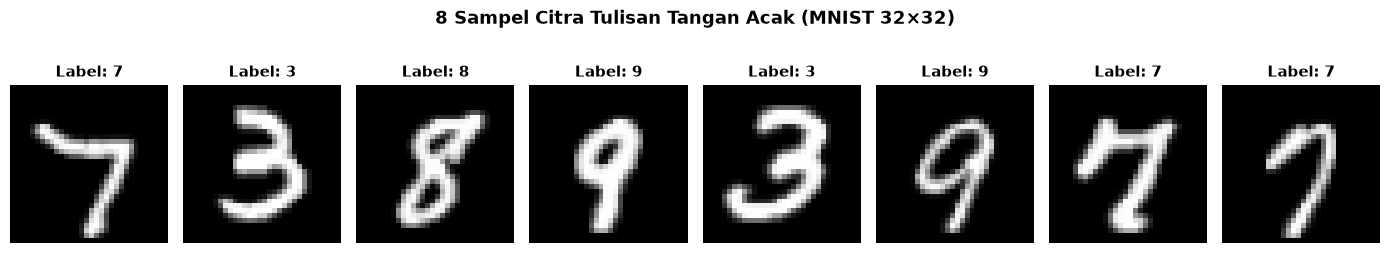

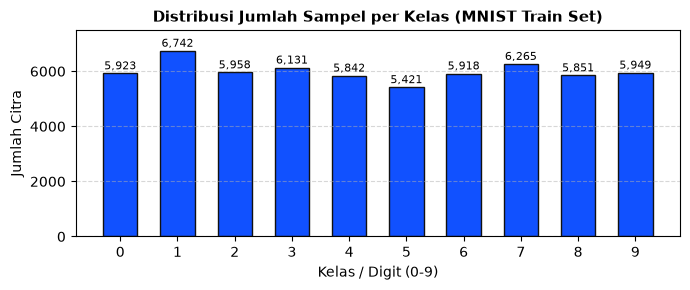

In [3]:
# Visualisasi 8 sampel gambar acak dari dataset
random_indices = np.random.choice(len(train_dataset), size=8, replace=False)

fig, axs = plt.subplots(1, 8, figsize=(14, 2.5))
for ax, sample_idx in zip(axs, random_indices):
    img, label = train_dataset[sample_idx]
    img_np = img.squeeze().numpy() * 0.3081 + 0.1307

    ax.imshow(img_np, cmap='gray')
    ax.set_title(f"Label: {label}", fontsize=11, fontweight='bold')
    ax.axis('off')

plt.suptitle(
    "8 Sampel Citra Tulisan Tangan Acak (MNIST 32×32)",
    fontsize=13,
    fontweight='bold',
    y=1.05
)
plt.tight_layout()
plt.show()

# Cek distribusi jumlah sampel per kelas pada training set
labels_train = np.array([train_dataset[i][1] for i in range(len(train_dataset))])
counts = np.bincount(labels_train)

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.bar(range(10), counts, color='#1151FF', edgecolor='#111111', width=0.6)
ax.set_title("Distribusi Jumlah Sampel per Kelas (MNIST Train Set)", fontsize=11, fontweight='bold')
ax.set_xlabel("Kelas / Digit (0-9)")
ax.set_ylabel("Jumlah Citra")
ax.set_xticks(range(10))
ax.grid(axis='y', linestyle='--', alpha=0.5)
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 50, f"{yval:,}", ha='center', va='bottom', fontsize=8)
plt.ylim(0, 7500)
plt.tight_layout()
plt.show()

## 3. Implementasi Arsitektur LeNet-5 (PyTorch `nn.Module`)

Berikut adalah definisi kelas `LeNet5` yang disalin persis dari naskah slide perkuliahan (*Slide Frame 61–63*):
- Menggunakan fungsi aktivasi historis **`nn.Tanh()`**
- Menggunakan subsampling **`nn.AvgPool2d(kernel_size=2, stride=2)`**
- Pembagian rapi menjadi dua blok: `self.feature_extractor` dan `self.classifier`
- Menggunakan perataan tensor `torch.flatten(x, 1)` untuk menyambungkan representasi 2D ke dense layers.

In [4]:
class LeNet5(nn.Module):
    """
    Implementasi arsitektur LeNet-5 (1998) menggunakan PyTorch.
    Arsitektur ini didesain untuk input gambar grayscale 32x32 piksel.
    Salinan persis dari Slide Frame 61-63, Pertemuan 04 Deep Learning ITERA.
    """
    def __init__(self):
        super().__init__()

        # === 1. BAGIAN EKSTRAKTOR FITUR ===
        self.feature_extractor = nn.Sequential(
            # Lapisan C1: Konvolusi pertama
            nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1),
            nn.Tanh(),
            
            # Lapisan S2: Subsampling (Average Pooling)
            nn.AvgPool2d(kernel_size=2, stride=2),
            
            # Lapisan C3: Konvolusi kedua  
            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1),
            nn.Tanh(),
            
            # Lapisan S4: Subsampling (Average Pooling)
            nn.AvgPool2d(kernel_size=2, stride=2)
        )

        # === 2. BAGIAN KLASIFIKATOR ===
        self.classifier = nn.Sequential(
            # Lapisan C5 (sebagai Fully Connected pertama)
            nn.Linear(in_features=16 * 5 * 5, out_features=120),
            nn.Tanh(),

            # Lapisan F6 (Fully Connected kedua)
            nn.Linear(in_features=120, out_features=84),
            nn.Tanh(),

            # Lapisan Output (10 kelas untuk digit 0-9)
            nn.Linear(in_features=84, out_features=10)
        )

    def forward(self, x):
        """
        Mendefinisikan alur maju (forward pass) dari data melalui model.
        """
        # Lewatkan input melalui ekstraktor fitur
        x = self.feature_extractor(x)
        
        # Flatten output dari 2D menjadi 1D sebelum masuk ke classifier
        # Dimensi 0 (batch) dipertahankan
        x = torch.flatten(x, 1)
        
        # Lewatkan data yang sudah diratakan melalui classifier
        logits = self.classifier(x)
        return logits

# Inisialisasi model dan kirim ke device aktif
model = LeNet5().to(device)
print("Model LeNet-5 berhasil diinstansiasi!")

Model LeNet-5 berhasil diinstansiasi!


## 4. Ringkasan Arsitektur dengan `torchinfo`

Pada *Slide Frame 64* (baris 1790–1819), kita menjalankan ringkasan arsitektur LeNet-5 untuk memvalidasi dimensi tensor pada setiap layer dan jumlah bobot latih.

In [5]:
print("=" * 65)
print("         Ringkasan Arsitektur LeNet-5 (Torchinfo)")
print("=" * 65)

# Input dummy berukuran (batch_size=1, channels=1, height=32, width=32)
ringkasan_model = summary(
    model, 
    input_size=(1, 1, 32, 32), 
    col_names=["input_size", "output_size", "num_params", "mult_adds"],
    device=device
)
print(ringkasan_model)

         Ringkasan Arsitektur LeNet-5 (Torchinfo)
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Mult-Adds
LeNet5                                   [1, 1, 32, 32]            [1, 10]                   --                        --
├─Sequential: 1-1                        [1, 1, 32, 32]            [1, 16, 5, 5]             --                        --
│    └─Conv2d: 2-1                       [1, 1, 32, 32]            [1, 6, 28, 28]            156                       122,304
│    └─Tanh: 2-2                         [1, 6, 28, 28]            [1, 6, 28, 28]            --                        --
│    └─AvgPool2d: 2-3                    [1, 6, 28, 28]            [1, 6, 14, 14]            --                        --
│    └─Conv2d: 2-4                       [1, 6, 14, 14]            [1, 16, 10, 10]           2,416                     241,600
│    └─Tanh: 2-5                         [1, 16, 10, 10]           [1, 16, 10, 

## 5. Analisis Perubahan Bentuk Tensor (*Output Shape Progression*)

Mari kita lacak (*trace*) transformasi dimensi tensor secara empiris di setiap layer menggunakan *forward hook*, lalu kita bandingkan rantai shape aktual terhadap rumus dari Notebook 1:

$$\text{Input: } [1, 1, 32, 32] \to C1: [1, 6, 28, 28] \to S2: [1, 6, 14, 14] \to C3: [1, 16, 10, 10] \to S4: [1, 16, 5, 5] \to \text{Flatten: } [1, 400] \to [1, 120] \to [1, 84] \to [1, 10]$$

In [6]:
shape_log = []

# Mendaftarkan hook sementara pada sub-layer
hooks = []
for nama, modul in model.named_modules():
    if isinstance(modul, (nn.Conv2d, nn.AvgPool2d, nn.Linear)):
        def make_hook(nama_layer):
            def hook(m, inp, out):
                shape_log.append((nama_layer, list(out.shape)))
            return hook
        hooks.append(modul.register_forward_hook(make_hook(nama)))

# Forward pass dengan 1 batch dummy
x_dummy = torch.zeros(1, 1, 32, 32, device=device)
_ = model(x_dummy)

# Lepas hooks setelah pencatatan selesai
for h in hooks:
    h.remove()

print("Rantai Transformasi Dimensi Tensor LeNet-5:")
print(f"{'Nama Sub-Layer':<35} | {'Bentuk Tensor Output':<25} | {'Status Slide Frame 65'}")
print("-" * 80)

# Rantai target shape sesuai slide frame 65 (baris 1825-1845)
target_shapes = {
    "feature_extractor.0": [1, 6, 28, 28],   # C1
    "feature_extractor.2": [1, 6, 14, 14],   # S2
    "feature_extractor.3": [1, 16, 10, 10],  # C3
    "feature_extractor.5": [1, 16, 5, 5],    # S4
    "classifier.0": [1, 120],                # C5 (FC1)
    "classifier.2": [1, 84],                 # F6 (FC2)
    "classifier.4": [1, 10]                  # Output Logits
}

for nama, out_shape in shape_log:
    target = target_shapes.get(nama, None)
    cocok = (out_shape == target)
    print(f"{nama:<35} | {str(out_shape):<25} | {'✓ MATCH' if cocok else 'MISMATCH'}")
    assert cocok, f"Bentuk layer {nama} tidak sesuai target slide!"

print("\n[VALIDASI SUKSES] Rantai shape 32 -> 28 -> 14 -> 10 -> 5 -> 120 -> 84 -> 10 lolos assert 100%!")

Rantai Transformasi Dimensi Tensor LeNet-5:
Nama Sub-Layer                      | Bentuk Tensor Output      | Status Slide Frame 65
--------------------------------------------------------------------------------
feature_extractor.0                 | [1, 6, 28, 28]            | ✓ MATCH
feature_extractor.2                 | [1, 6, 14, 14]            | ✓ MATCH
feature_extractor.3                 | [1, 16, 10, 10]           | ✓ MATCH
feature_extractor.5                 | [1, 16, 5, 5]             | ✓ MATCH
classifier.0                        | [1, 120]                  | ✓ MATCH
classifier.2                        | [1, 84]                   | ✓ MATCH
classifier.4                        | [1, 10]                   | ✓ MATCH

[VALIDASI SUKSES] Rantai shape 32 -> 28 -> 14 -> 10 -> 5 -> 120 -> 84 -> 10 lolos assert 100%!


## 6. Visualisasi Aliran Representasi Piksel & Feature Map per Tahapan LeNet-5

Untuk memahami intuisi bagaimana sebuah citra diproses di dalam *deep neural network*, mari kita lacak sebuah sampel citra MNIST secara bertahap (*layer-by-layer*) melalui saluran komputasi LeNet-5:
1. **Representasi Spasial 2D (Ekstraktor Fitur):**
   - **Input:**  	imes 32 	imes 32$ (citra grayscale asli)
   - **C1 (Conv2d + Tanh):**  	imes 28 	imes 28$ (6 peta fitur / saluran)
   - **S2 (AvgPool2d):**  	imes 14 	imes 14$ (subsampling resolusi spasial)
   - **C3 (Conv2d + Tanh):**  	imes 10 	imes 10$ (16 peta fitur kombinasi)
   - **S4 (AvgPool2d):**  	imes 5 	imes 5$ (subsampling akhir, total  	imes 5 	imes 5 = 400$ nilai piksel)
2. **Representasi Vektor 1D (Klasifikator Dense):**
   - **Flatten:** Vektor 1D berukuran $
   - **C5 / FC1:** Vektor 1D berukuran $ (aktivasi Tanh)
   - **F6 / FC2:** Vektor 1D berukuran $ (aktivasi Tanh)
   - **Output Logits:** Vektor 1D berukuran $ (skor prediksi untuk digit 0–9)

Setiap tahapan 2D divisualisasikan dalam bentuk *image grid* peta fitur, sedangkan tahapan 1D disajikan dalam diagram batang (*bar plot*) dan ringkasan nilai array numerik.

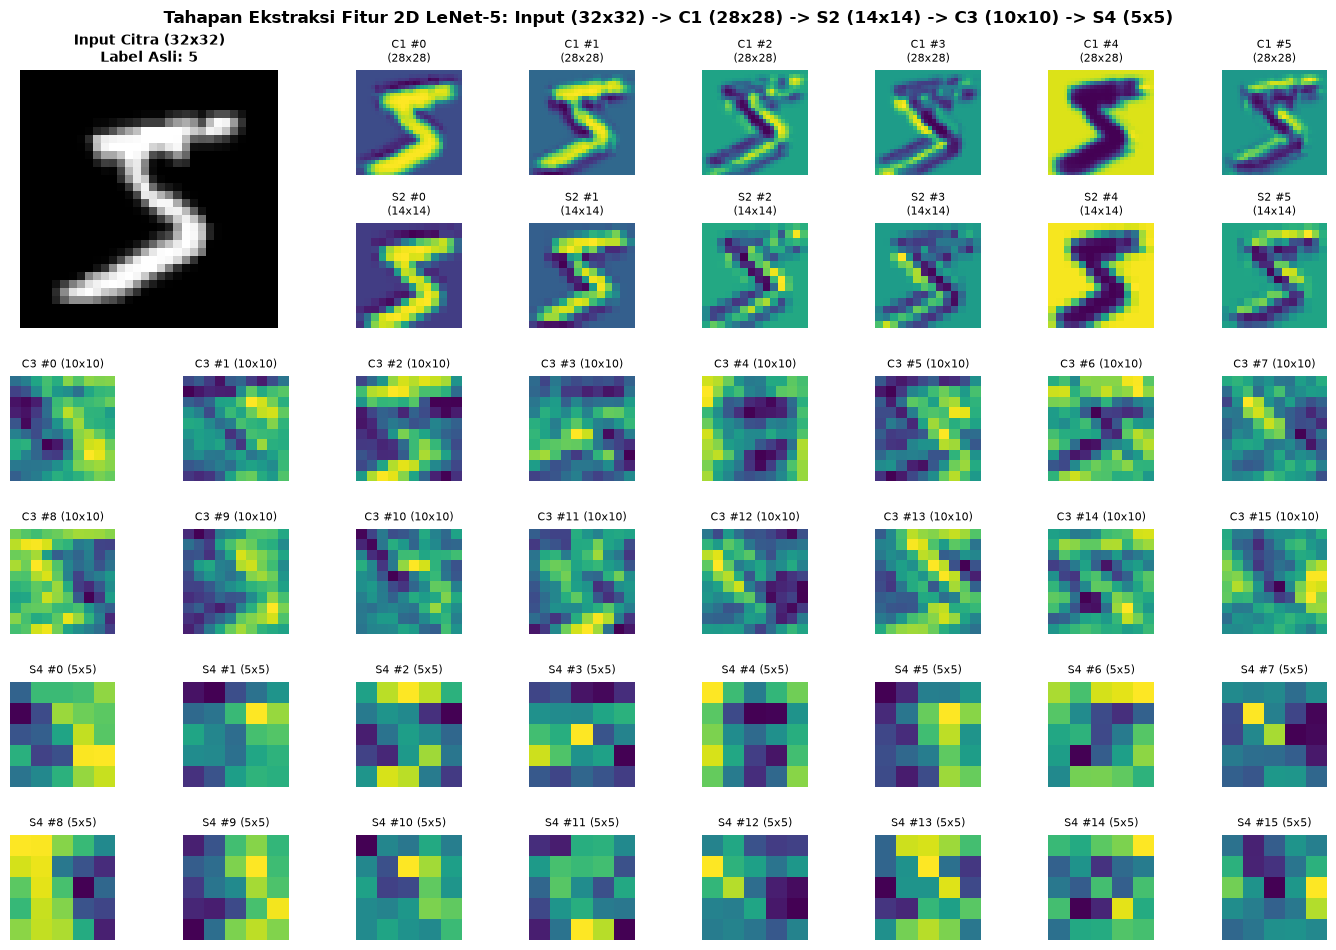

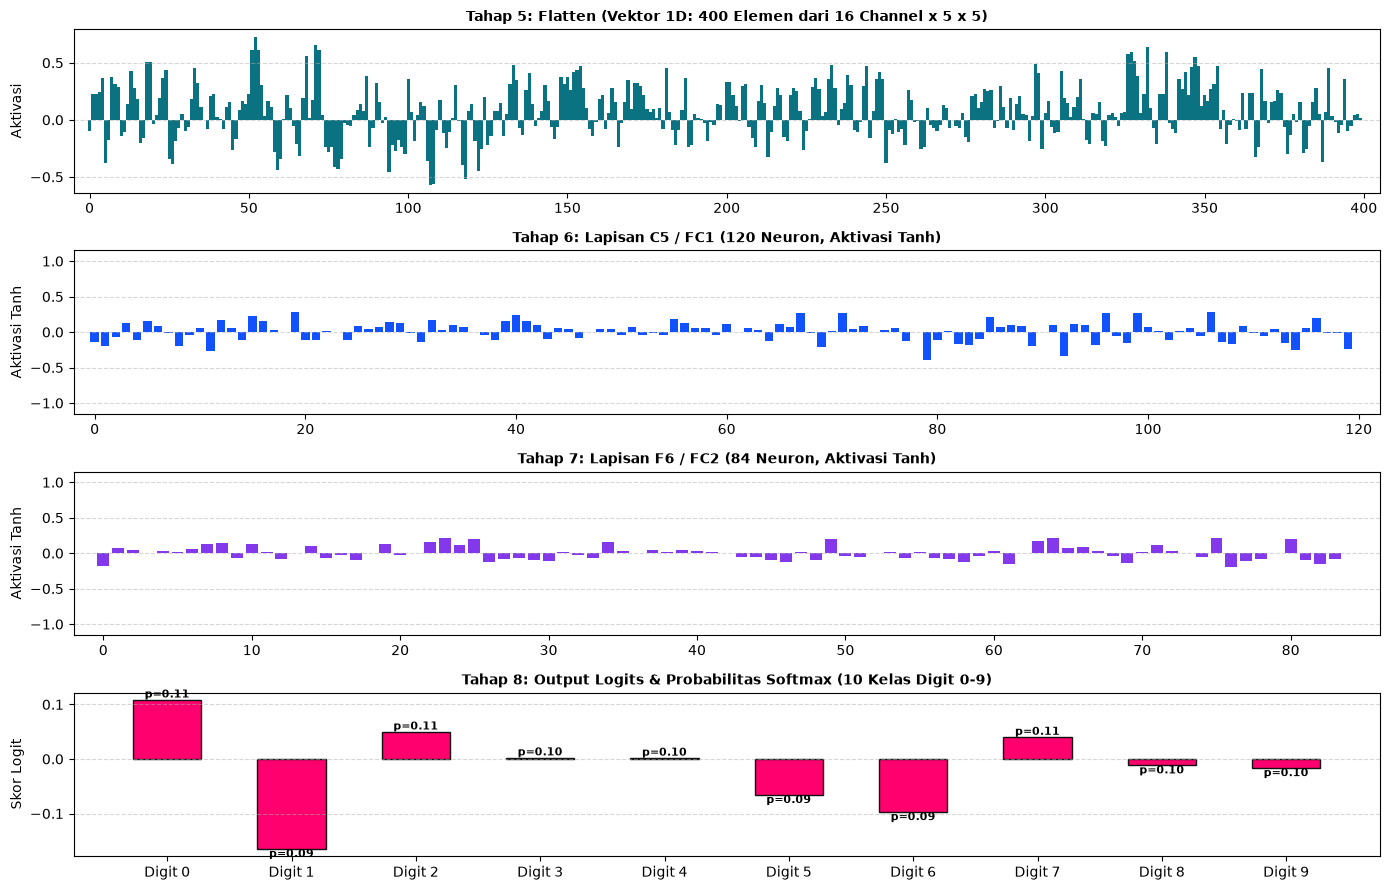

INSPEKSI NILAI PIKSEL & ARRAY AKTIVASI SETIAP TAHAPAN LENET-5

[Tahap 1 - C1: 6 Channel (28x28)]
Bentuk Tensor       : [1, 6, 28, 28]
Rentang Nilai C1    : min=-0.9994, max=0.9906, mean=-0.0436
Cuplikan Nilai Piksel C1 Channel #0 (Sub-matriks 5x5 sudut kiri atas):
[[-0.311 -0.311 -0.311 -0.311 -0.311]
 [-0.311 -0.311 -0.311 -0.311 -0.311]
 [-0.311 -0.311 -0.311 -0.311 -0.311]
 [-0.311 -0.311 -0.311 -0.311 -0.316]
 [-0.311 -0.311 -0.311 -0.316 -0.38 ]]

[Tahap 2 - S2: 6 Channel (14x14)]
Bentuk Tensor       : [1, 6, 14, 14]
Rentang Nilai S2    : min=-0.9991, max=0.9825, mean=-0.0436
Cuplikan Nilai Piksel S2 Channel #0 (Sub-matriks 5x5 sudut kiri atas):
[[-0.311 -0.311 -0.311 -0.311 -0.311]
 [-0.311 -0.311 -0.328 -0.351 -0.415]
 [-0.311 -0.312 -0.437 -0.461 -0.362]
 [-0.311 -0.311 -0.294  0.22   0.765]
 [-0.311 -0.311 -0.401  0.311  0.836]]

[Tahap 3 - C3: 16 Channel (10x10)]
Bentuk Tensor       : [1, 16, 10, 10]
Rentang Nilai C3    : min=-0.6525, max=0.8469, mean=0.0708
Cuplikan Nilai Pi

In [7]:
# 1. Ambil 1 sampel citra dari train_dataset (Digit MNIST)
sample_idx = 0
sample_img, sample_label = train_dataset[sample_idx]
sample_input = sample_img.unsqueeze(0).to(device)

# 2. Forward pass lapis-demi-lapis secara deterministik
model.eval()
with torch.no_grad():
    # Ekstraktor Fitur (2D)
    c1_act = model.feature_extractor[1](model.feature_extractor[0](sample_input))   # [1, 6, 28, 28]
    s2_act = model.feature_extractor[2](c1_act)                                    # [1, 6, 14, 14]
    c3_act = model.feature_extractor[4](model.feature_extractor[3](s2_act))       # [1, 16, 10, 10]
    s4_act = model.feature_extractor[5](c3_act)                                    # [1, 16, 5, 5]
    
    # Klasifikator Dense (1D)
    flatten_act = torch.flatten(s4_act, 1)                                          # [1, 400]
    c5_act = model.classifier[1](model.classifier[0](flatten_act))                 # [1, 120]
    f6_act = model.classifier[3](model.classifier[2](c5_act))                     # [1, 84]
    logits_act = model.classifier[4](f6_act)                                       # [1, 10]
    probs_act = torch.softmax(logits_act, dim=1)                                   # [1, 10]

# Konversi tensor ke NumPy untuk visualisasi dan inspeksi numerik
c1_np = c1_act.squeeze(0).cpu().numpy()
s2_np = s2_act.squeeze(0).cpu().numpy()
c3_np = c3_act.squeeze(0).cpu().numpy()
s4_np = s4_act.squeeze(0).cpu().numpy()
flatten_np = flatten_act.squeeze(0).cpu().numpy()
c5_np = c5_act.squeeze(0).cpu().numpy()
f6_np = f6_act.squeeze(0).cpu().numpy()
logits_np = logits_act.squeeze(0).cpu().numpy()
probs_np = probs_act.squeeze(0).cpu().numpy()

# =========================================================================
# VISUALISASI BAGIAN 1: REPRESENTASI SPASIAL 2D (INPUT -> C1 -> S2 -> C3 -> S4)
# =========================================================================
fig_2d = plt.figure(figsize=(15, 10))
gs = fig_2d.add_gridspec(6, 8, hspace=0.45, wspace=0.25, top=0.92, bottom=0.05, left=0.05, right=0.95)

# Tahap 0: Input Image (merentang 2 baris, 2 kolom)
ax_in = fig_2d.add_subplot(gs[0:2, 0:2])
raw_img = sample_img.squeeze().numpy() * 0.3081 + 0.1307  # Denormalisasi agar kembali ke skala [0, 1]
ax_in.imshow(raw_img, cmap='gray')
ax_in.set_title(f'Input Citra (32x32)\nLabel Asli: {sample_label}', fontsize=10, fontweight='bold')
ax_in.axis('off')

# Tahap 1: C1 Feature Maps (6 channel, ukuran 28x28)
for ch in range(6):
    ax = fig_2d.add_subplot(gs[0, 2 + ch])
    ax.imshow(c1_np[ch], cmap='viridis')
    ax.set_title(f'C1 #{ch}\n(28x28)', fontsize=8)
    ax.axis('off')

# Tahap 2: S2 Subsampling Maps (6 channel, ukuran 14x14)
for ch in range(6):
    ax = fig_2d.add_subplot(gs[1, 2 + ch])
    ax.imshow(s2_np[ch], cmap='viridis')
    ax.set_title(f'S2 #{ch}\n(14x14)', fontsize=8)
    ax.axis('off')

# Tahap 3: C3 Feature Maps (16 channel, ukuran 10x10, 2 baris x 8 kolom)
for ch in range(16):
    r = 2 + (ch // 8)
    c = ch % 8
    ax = fig_2d.add_subplot(gs[r, c])
    ax.imshow(c3_np[ch], cmap='viridis')
    ax.set_title(f'C3 #{ch} (10x10)', fontsize=8)
    ax.axis('off')

# Tahap 4: S4 Subsampling Maps (16 channel, ukuran 5x5, 2 baris x 8 kolom)
for ch in range(16):
    r = 4 + (ch // 8)
    c = ch % 8
    ax = fig_2d.add_subplot(gs[r, c])
    ax.imshow(s4_np[ch], cmap='viridis')
    ax.set_title(f'S4 #{ch} (5x5)', fontsize=8)
    ax.axis('off')

plt.suptitle('Tahapan Ekstraksi Fitur 2D LeNet-5: Input (32x32) -> C1 (28x28) -> S2 (14x14) -> C3 (10x10) -> S4 (5x5)', fontsize=12, fontweight='bold')
plt.show()

# =========================================================================
# VISUALISASI BAGIAN 2: REPRESENTASI VEKTOR 1D (FLATTEN -> C5 -> F6 -> OUTPUT)
# =========================================================================
fig_1d, axs_1d = plt.subplots(4, 1, figsize=(14, 9))

# Tahap 5: Flatten (400 elemen)
axs_1d[0].bar(range(400), flatten_np, color='#0A7281', width=1.0, edgecolor='none')
axs_1d[0].set_title('Tahap 5: Flatten (Vektor 1D: 400 Elemen dari 16 Channel x 5 x 5)', fontsize=10, fontweight='bold')
axs_1d[0].set_xlim(-5, 405)
axs_1d[0].set_ylabel('Aktivasi')
axs_1d[0].grid(axis='y', linestyle='--', alpha=0.5)

# Tahap 6: C5 / FC1 (120 neuron)
axs_1d[1].bar(range(120), c5_np, color='#1151FF', width=0.8, edgecolor='none')
axs_1d[1].set_title('Tahap 6: Lapisan C5 / FC1 (120 Neuron, Aktivasi Tanh)', fontsize=10, fontweight='bold')
axs_1d[1].set_xlim(-2, 122)
axs_1d[1].set_ylim(-1.15, 1.15)
axs_1d[1].set_ylabel('Aktivasi Tanh')
axs_1d[1].grid(axis='y', linestyle='--', alpha=0.5)

# Tahap 7: F6 / FC2 (84 neuron)
axs_1d[2].bar(range(84), f6_np, color='#8338EC', width=0.8, edgecolor='none')
axs_1d[2].set_title('Tahap 7: Lapisan F6 / FC2 (84 Neuron, Aktivasi Tanh)', fontsize=10, fontweight='bold')
axs_1d[2].set_xlim(-2, 86)
axs_1d[2].set_ylim(-1.15, 1.15)
axs_1d[2].set_ylabel('Aktivasi Tanh')
axs_1d[2].grid(axis='y', linestyle='--', alpha=0.5)

# Tahap 8: Output Logits (10 kelas digit 0-9)
bars = axs_1d[3].bar(range(10), logits_np, color='#FF006E', width=0.55, edgecolor='#111111')
axs_1d[3].set_title('Tahap 8: Output Logits & Probabilitas Softmax (10 Kelas Digit 0-9)', fontsize=10, fontweight='bold')
axs_1d[3].set_xticks(range(10))
axs_1d[3].set_xticklabels([f'Digit {i}' for i in range(10)])
axs_1d[3].set_ylabel('Skor Logit')
axs_1d[3].grid(axis='y', linestyle='--', alpha=0.5)
for i, bar in enumerate(bars):
    prob_text = f'p={probs_np[i]:.2f}'
    ypos = bar.get_height()
    va = 'bottom' if ypos >= 0 else 'top'
    axs_1d[3].text(bar.get_x() + bar.get_width()/2, ypos, prob_text, ha='center', va=va, fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

# =========================================================================
# BAGIAN 3: CETAK NILAI PIKSEL & AKTIVASI ARRAY TIAP TAHAPAN
# =========================================================================
print('=' * 75)
print('INSPEKSI NILAI PIKSEL & ARRAY AKTIVASI SETIAP TAHAPAN LENET-5')
print('=' * 75)

print('\n[Tahap 1 - C1: 6 Channel (28x28)]')
print(f'Bentuk Tensor       : {list(c1_act.shape)}')
print(f'Rentang Nilai C1    : min={c1_np.min():.4f}, max={c1_np.max():.4f}, mean={c1_np.mean():.4f}')
print('Cuplikan Nilai Piksel C1 Channel #0 (Sub-matriks 5x5 sudut kiri atas):')
print(np.round(c1_np[0, :5, :5], 3))

print('\n[Tahap 2 - S2: 6 Channel (14x14)]')
print(f'Bentuk Tensor       : {list(s2_act.shape)}')
print(f'Rentang Nilai S2    : min={s2_np.min():.4f}, max={s2_np.max():.4f}, mean={s2_np.mean():.4f}')
print('Cuplikan Nilai Piksel S2 Channel #0 (Sub-matriks 5x5 sudut kiri atas):')
print(np.round(s2_np[0, :5, :5], 3))

print('\n[Tahap 3 - C3: 16 Channel (10x10)]')
print(f'Bentuk Tensor       : {list(c3_act.shape)}')
print(f'Rentang Nilai C3    : min={c3_np.min():.4f}, max={c3_np.max():.4f}, mean={c3_np.mean():.4f}')
print('Cuplikan Nilai Piksel C3 Channel #0 (Sub-matriks 5x5 sudut kiri atas):')
print(np.round(c3_np[0, :5, :5], 3))

print('\n[Tahap 4 - S4: 16 Channel (5x5)]')
print(f'Bentuk Tensor       : {list(s4_act.shape)}')
print(f'Rentang Nilai S4    : min={s4_np.min():.4f}, max={s4_np.max():.4f}, mean={s4_np.mean():.4f}')
print('Matriks Lengkap Nilai Piksel S4 Channel #0 (5x5 Piksel Spasial Akhir):')
print(np.round(s4_np[0], 3))

print('\n[Tahap 5 - Flatten: Vektor 1D]')
print(f'Bentuk Tensor       : {list(flatten_act.shape)}')
print('20 Nilai Piksel Pertama dari 400 Elemen:')
print(np.round(flatten_np[:20], 3))

print('\n[Tahap 6 - C5 / FC1: Vektor 1D]')
print(f'Bentuk Tensor       : {list(c5_act.shape)}')
print('20 Nilai Aktivasi Pertama dari 120 Neuron:')
print(np.round(c5_np[:20], 3))

print('\n[Tahap 7 - F6 / FC2: Vektor 1D]')
print(f'Bentuk Tensor       : {list(f6_act.shape)}')
print('20 Nilai Aktivasi Pertama dari 84 Neuron:')
print(np.round(f6_np[:20], 3))

print('\n[Tahap 8 - Output Logits & Softmax Probs: 10 Kelas]')
print(f'Bentuk Tensor       : {list(logits_act.shape)}')
print('Array Skor Logits   : ', np.round(logits_np, 3))
print('Array Prob Softmax  : ', np.round(probs_np, 3))
print(f'Prediksi Kelas Awal : Digit {int(np.argmax(logits_np))} (Keyakinan: {probs_np.max()*100:.2f}%)')
print('Catatan: Bobot model saat ini masih inisialisasi acak (belum dilatih).')
print('=' * 75)


## 7. Breakdown Jumlah Parameter per Layer (Total 61.706)

Slide Pertemuan 04 (*Frame 66*, baris 1851–1870) merinci jumlah parameter pada setiap layer:
- **C1 (Conv2d):** $(5 \times 5 \times 1 + 1) \times 6 = 26 \times 6 = \mathbf{156}$
- **C3 (Conv2d):** $(5 \times 5 \times 6 + 1) \times 16 = 151 \times 16 = \mathbf{2.416}$
- **C5 (Linear 1):** $(400 + 1) \times 120 = \mathbf{48.120}$
- **F6 (Linear 2):** $(120 + 1) \times 84 = \mathbf{10.164}$
- **Output (Linear 3):** $(84 + 1) \times 10 = \mathbf{850}$
- **Total Parameter:** $156 + 2.416 + 48.120 + 10.164 + 850 = \mathbf{61.706}$

Tabel Parameter per Layer LeNet-5:
Nama Layer                     | Jumlah Parameter   | Persentase (%) 
----------------------------------------------------------------------
feature_extractor.0            | 156                | 0.25          %
feature_extractor.3            | 2,416              | 3.92          %
classifier.0                   | 48,120             | 77.98         %
classifier.2                   | 10,164             | 16.47         %
classifier.4                   | 850                | 1.38          %
----------------------------------------------------------------------
TOTAL SELURUH MODEL            | 61,706             | 100.00%

[VALIDASI SUKSES] Total tepat 61.706 parameter persis dengan slide frame 66!


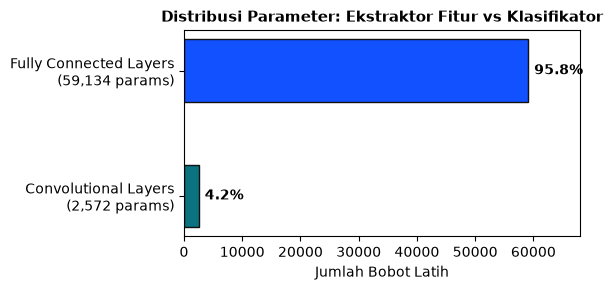

In [8]:
breakdown_param = {}
total_hitung = 0

for nama, param in model.named_parameters():
    jml = param.numel()
    nama_induk = nama.rsplit('.', 1)[0]
    breakdown_param[nama_induk] = breakdown_param.get(nama_induk, 0) + jml
    total_hitung += jml

print("Tabel Parameter per Layer LeNet-5:")
print(f"{'Nama Layer':<30} | {'Jumlah Parameter':<18} | {'Persentase (%)':<15}")
print("-" * 70)

target_params = {
    "feature_extractor.0": 156,
    "feature_extractor.3": 2416,
    "classifier.0": 48120,
    "classifier.2": 10164,
    "classifier.4": 850
}

for layer, jml in breakdown_param.items():
    persen = (jml / total_hitung) * 100
    target = target_params.get(layer, None)
    print(f"{layer:<30} | {jml:<18,} | {persen:<14.2f}%")
    assert jml == target, f"Parameter layer {layer} mismatch! Diharapkan {target}, didapat {jml}"

assert total_hitung == 61706, f"Total parameter {total_hitung} != 61.706!"
print("-" * 70)
print(f"{'TOTAL SELURUH MODEL':<30} | {total_hitung:<18,} | 100.00%")
print("\n[VALIDASI SUKSES] Total tepat 61.706 parameter persis dengan slide frame 66!")

# Visualisasi Distribusi Bobot: Conv vs Fully Connected
conv_params = breakdown_param["feature_extractor.0"] + breakdown_param["feature_extractor.3"]
fc_params = breakdown_param["classifier.0"] + breakdown_param["classifier.2"] + breakdown_param["classifier.4"]

fig, ax = plt.subplots(figsize=(6, 3))
kategori = [f"Convolutional Layers\n({conv_params:,} params)", f"Fully Connected Layers\n({fc_params:,} params)"]
nilai = [conv_params, fc_params]
warna = ['#0A7281', '#1151FF']

ax.barh(kategori, nilai, color=warna, edgecolor='#111111', height=0.5)
ax.set_title("Distribusi Parameter: Ekstraktor Fitur vs Klasifikator", fontsize=11, fontweight='bold')
ax.set_xlabel("Jumlah Bobot Latih")
for idx, v in enumerate(nilai):
    pers = (v / total_hitung) * 100
    ax.text(v + 1000, idx, f"{pers:.1f}%", va='center', fontweight='bold')
plt.xlim(0, 68000)
plt.tight_layout()
plt.show()

## 8. Persiapan Pelatihan: Loss Function & Optimizer

Sesuai *Slide Frame 68* (baris 1920–1925):
```python
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
```
- `nn.CrossEntropyLoss`: Mengombinasikan `LogSoftmax` dan `NLLLoss` (Negative Log Likelihood) secara numerik stabil untuk klasifikasi multi-kelas.
- `optim.Adam`: Algoritma optimasi berbasis momen adaptif dengan *learning rate* $\alpha = 0.001$.

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Komponen Pelatihan:")
print(f"1. Loss Function : {criterion}")
print(f"2. Optimizer     : {optimizer.__class__.__name__} (lr={optimizer.param_groups[0]['lr']})")

Komponen Pelatihan:
1. Loss Function : CrossEntropyLoss()
2. Optimizer     : Adam (lr=0.001)


## 9. Alur 5 Langkah Baku *Training Loop* (Slide Frame 69)

Pada setiap *mini-batch*, alur wajib pelatihan terdiri dari 5 langkah terurut:
1. `optimizer.zero_grad()` — Reset gradien akumulasi dari iterasi sebelumnya.
2. `outputs = model(images)` — *Forward pass*: menghitung prediksi logits.
3. `loss = criterion(outputs, labels)` — Menghitung nilai *loss*.
4. `loss.backward()` — *Backward pass*: menghitung turunan parsial gradien $\frac{\partial L}{\partial w}$.
5. `optimizer.step()` — Pembaruan bobot (*weight update*) berdasarkan gradien: $w \leftarrow w - \eta \nabla L$.

In [10]:
def latih_satu_epoch(model, dataloader, criterion, optimizer, device):
    """Melatih model selama satu epoch penuh dengan 5 langkah standar."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        
        # --- ALUR 5 LANGKAH STANDAR (FRAME 69) ---
        optimizer.zero_grad()               # 1. Reset gradien akumulasi
        outputs = model(images)             # 2. Forward pass: hitung output
        loss = criterion(outputs, labels)   # 3. Hitung loss
        loss.backward()                     # 4. Backward: hitung gradien dL/dw
        optimizer.step()                    # 5. Update bobot (w = w - lr*grad)
        # ------------------------------------------
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
        
    epoch_loss = running_loss / total
    epoch_acc = (correct / total) * 100.0
    return epoch_loss, epoch_acc


def evaluasi(model, dataloader, criterion, device):
    """Mengevaluasi model pada dataset validasi/uji (Inference Mode, Frame 70)."""
    model.eval()  # Mode evaluasi
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():  # Matikan graf komputasi gradien (hemat RAM & percepat inferensi)
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            
    val_loss = running_loss / total
    val_acc = (correct / total) * 100.0
    return val_loss, val_acc

print("Fungsi latih_satu_epoch() dan evaluasi() siap dijalankan.")

Fungsi latih_satu_epoch() dan evaluasi() siap dijalankan.


## 10. Menjalankan Pelatihan Selama 5 Epoch

Mari kita latih LeNet-5 selama 5 epoch dan catat riwayat metrik *loss* serta akurasi pada data latih dan data uji.

In [11]:
NUM_EPOCHS = 5
history = {
    'train_loss': [],
    'train_acc': [],
    'test_loss': [],
    'test_acc': []
}

print(f"Memulai Pelatihan LeNet-5 pada {device} ({NUM_EPOCHS} Epoch)...")
print("-" * 68)
waktu_mulai_total = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    train_loss, train_acc = latih_satu_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluasi(model, test_loader, criterion, device)
    durasi = time.time() - t0
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    
    print(f"Epoch [{epoch}/{NUM_EPOCHS}] ({durasi:.1f}s) | "
          f"Train Loss: {train_loss:.4f} - Acc: {train_acc:.2f}% | "
          f"Test Loss: {test_loss:.4f} - Acc: {test_acc:.2f}%")

total_durasi = time.time() - waktu_mulai_total
print("-" * 68)
print(f"Pelatihan Selesai dalam {total_durasi:.1f} detik! Akurasi Akhir: {history['test_acc'][-1]:.2f}%")
assert history['test_acc'][-1] > 95.0, f"Akurasi LeNet-5 terlalu rendah: {history['test_acc'][-1]}%"
print("✓ Model berhasil mencapai akurasi >95% pada data uji MNIST!")

Memulai Pelatihan LeNet-5 pada mps (5 Epoch)...
--------------------------------------------------------------------
Epoch [1/5] (10.9s) | Train Loss: 0.2390 - Acc: 93.16% | Test Loss: 0.0722 - Acc: 97.76%
Epoch [2/5] (10.1s) | Train Loss: 0.0676 - Acc: 97.96% | Test Loss: 0.0498 - Acc: 98.36%
Epoch [3/5] (9.9s) | Train Loss: 0.0479 - Acc: 98.53% | Test Loss: 0.0470 - Acc: 98.38%
Epoch [4/5] (10.2s) | Train Loss: 0.0376 - Acc: 98.80% | Test Loss: 0.0461 - Acc: 98.61%
Epoch [5/5] (10.0s) | Train Loss: 0.0301 - Acc: 99.09% | Test Loss: 0.0475 - Acc: 98.58%
--------------------------------------------------------------------
Pelatihan Selesai dalam 51.1 detik! Akurasi Akhir: 98.58%
✓ Model berhasil mencapai akurasi >95% pada data uji MNIST!


## 11. Studi Kasus: Bahaya Lupa Memanggil `zero_grad()`

Pada *Slide Frame 69* terdapat kotak peringatan penting:
> **Penting: Mengapa `zero_grad()` Wajib?**  
> Secara default di PyTorch, gradien di-**akumulasi** (*accumulated*). Jika tidak di-reset di awal setiap batch, gradien akan terus bertambah besar dan merusak arah pembaruan bobot!

Mari kita buktikan secara empiris bahaya ini dengan menjalankan 50 iterasi tanpa memanggil `zero_grad()`.

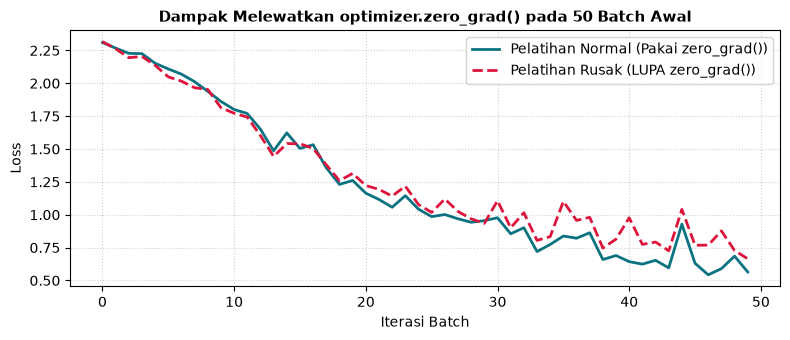

In [12]:
# Buat replika model baru untuk uji lupa zero_grad
model_rusak = LeNet5().to(device)
opt_rusak = optim.Adam(model_rusak.parameters(), lr=0.001)

loss_dengan_zero = []
loss_tanpa_zero = []

# Ambil 50 batch pertama dari train loader
iterator_batch = iter(train_loader)
batch_samples = [next(iterator_batch) for _ in range(50)]

# Eksperimen 1: Pelatihan BENAR (memakai zero_grad)
model_benar = LeNet5().to(device)
opt_benar = optim.Adam(model_benar.parameters(), lr=0.001)
for imgs, lbls in batch_samples:
    imgs, lbls = imgs.to(device), lbls.to(device)
    opt_benar.zero_grad()  # BENAR
    out = model_benar(imgs)
    l = criterion(out, lbls)
    l.backward()
    opt_benar.step()
    loss_dengan_zero.append(l.item())

# Eksperimen 2: Pelatihan SALAH (lupa zero_grad)
for imgs, lbls in batch_samples:
    imgs, lbls = imgs.to(device), lbls.to(device)
    # LUPA opt_rusak.zero_grad()!
    out = model_rusak(imgs)
    l = criterion(out, lbls)
    l.backward()
    opt_rusak.step()
    loss_tanpa_zero.append(l.item())

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(loss_dengan_zero, label="Pelatihan Normal (Pakai zero_grad())", color='#0A7281', linewidth=2)
ax.plot(loss_tanpa_zero, label="Pelatihan Rusak (LUPA zero_grad())", color='crimson', linestyle='--', linewidth=2)
ax.set_title("Dampak Melewatkan optimizer.zero_grad() pada 50 Batch Awal", fontsize=11, fontweight='bold')
ax.set_xlabel("Iterasi Batch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

## 12. Visualisasi Kurva Pembelajaran (Loss & Akurasi)

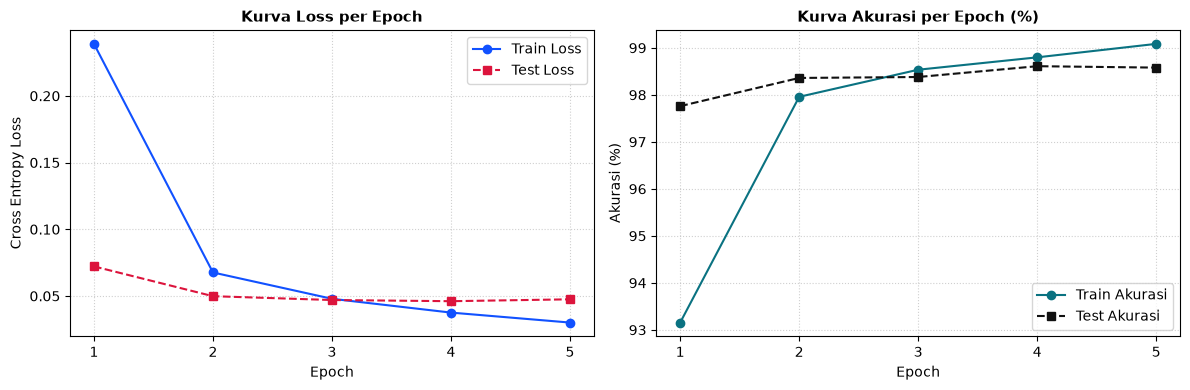

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Loss
axs[0].plot(range(1, NUM_EPOCHS + 1), history['train_loss'], 'o-', label='Train Loss', color='#1151FF')
axs[0].plot(range(1, NUM_EPOCHS + 1), history['test_loss'], 's--', label='Test Loss', color='crimson')
axs[0].set_title("Kurva Loss per Epoch", fontsize=11, fontweight='bold')
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Cross Entropy Loss")
axs[0].set_xticks(range(1, NUM_EPOCHS + 1))
axs[0].grid(True, linestyle=':', alpha=0.6)
axs[0].legend()

# Plot 2: Akurasi
axs[1].plot(range(1, NUM_EPOCHS + 1), history['train_acc'], 'o-', label='Train Akurasi', color='#0A7281')
axs[1].plot(range(1, NUM_EPOCHS + 1), history['test_acc'], 's--', label='Test Akurasi', color='#111111')
axs[1].set_title("Kurva Akurasi per Epoch (%)", fontsize=11, fontweight='bold')
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Akurasi (%)")
axs[1].set_xticks(range(1, NUM_EPOCHS + 1))
axs[1].grid(True, linestyle=':', alpha=0.6)
axs[1].legend()

plt.tight_layout()
plt.show()

## 13. Confusion Matrix & Analisis Kesalahan Prediksi

Untuk memahami di mana model membuat kekeliruan (misalnya angka '4' disangka '9', atau '7' disangka '1'), kita buat *Confusion Matrix* 10×10 secara murni menggunakan NumPy tanpa ketergantungan scikit-learn, lalu menampilkan galeri 12 sampel yang salah diprediksi.

/var/folders/h3/797kn0gx025b0p9fs3f_c2yw0000gn/T/ipykernel_65244/457199872.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


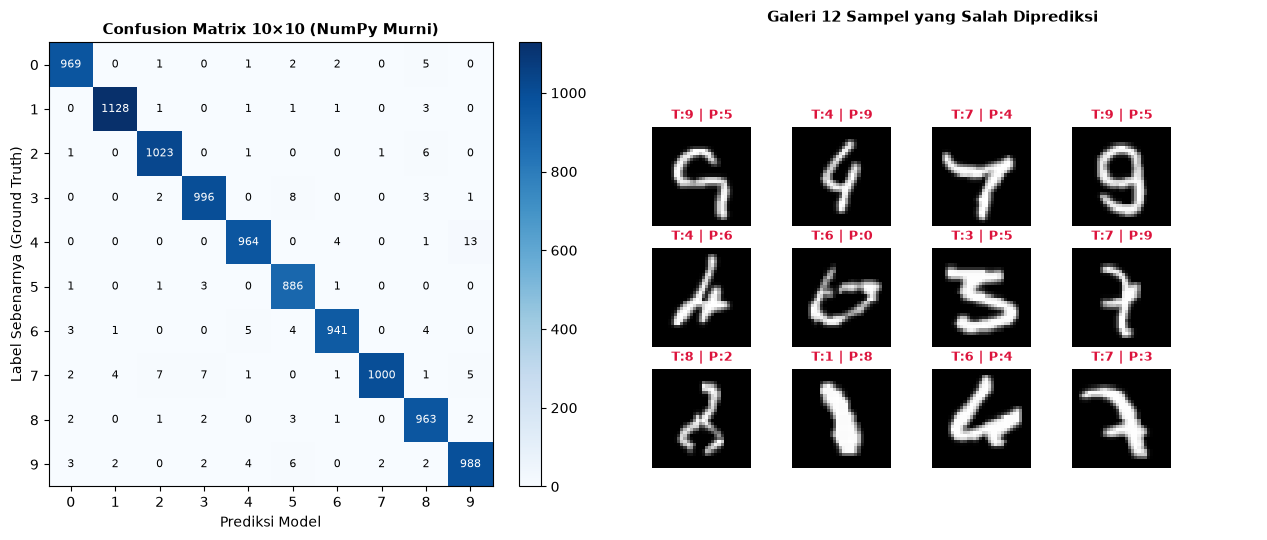

In [14]:
model.eval()
semua_pred = []
semua_label = []
salah_citra = []
salah_pred = []
salah_asli = []

with torch.no_grad():
    for images, labels in test_loader:
        images_dev = images.to(device)
        outputs = model(images_dev)
        _, preds = torch.max(outputs, 1)
        
        preds_cpu = preds.cpu().numpy()
        labels_cpu = labels.numpy()
        
        semua_pred.extend(preds_cpu)
        semua_label.extend(labels_cpu)
        
        # Kumpulkan sampel salah klasifikasi
        mask_salah = (preds_cpu != labels_cpu)
        if np.any(mask_salah) and len(salah_citra) < 12:
            salah_idx = np.where(mask_salah)[0]
            for idx in salah_idx:
                if len(salah_citra) < 12:
                    salah_citra.append(images[idx].squeeze().numpy())
                    salah_pred.append(preds_cpu[idx])
                    salah_asli.append(labels_cpu[idx])

# Hitung matriks kontingensi 10x10 secara murni dengan NumPy
cm = np.zeros((10, 10), dtype=int)
for t, p in zip(semua_label, semua_pred):
    cm[t, p] += 1

fig, axs = plt.subplots(1, 2, figsize=(14, 5.5))

# Subplot 1: Heatmap Confusion Matrix
im = axs[0].imshow(cm, cmap='Blues')
axs[0].set_title("Confusion Matrix 10×10 (NumPy Murni)", fontsize=11, fontweight='bold')
axs[0].set_xlabel("Prediksi Model")
axs[0].set_ylabel("Label Sebenarnya (Ground Truth)")
axs[0].set_xticks(range(10))
axs[0].set_yticks(range(10))
for i in range(10):
    for j in range(10):
        val = cm[i, j]
        color = "white" if val > cm.max() / 2 else "black"
        axs[0].text(j, i, str(val), ha='center', va='center', color=color, fontsize=8)
fig.colorbar(im, ax=axs[0], fraction=0.046, pad=0.04)

# Subplot 2: Galeri 12 Prediksi Salah (Error Analysis)
axs[1].axis('off')
axs[1].set_title("Galeri 12 Sampel yang Salah Diprediksi", fontsize=11, fontweight='bold', pad=15)

if len(salah_citra) > 0:
    for k in range(min(12, len(salah_citra))):
        sub_ax = fig.add_axes([0.55 + (k % 4) * 0.10, 0.58 - (k // 4) * 0.22, 0.085, 0.18])
        img_unnorm = salah_citra[k] * 0.3081 + 0.1307
        sub_ax.imshow(img_unnorm, cmap='gray')
        sub_ax.set_title(f"T:{salah_asli[k]} | P:{salah_pred[k]}", fontsize=9, color='crimson', fontweight='bold')
        sub_ax.axis('off')

plt.tight_layout()
plt.show()

## 14. Menyimpan Checkpoint Bobot Model (`.pth`)

Bobot model yang sudah dilatih ini akan disimpan ke dalam berkas `lenet5_mnist.pth`. Berkas ini akan langsung digunakan pada **Notebook 03 (Analisis & Eksperimen CNN)** untuk analisis *feature map* berhierarki tanpa perlu melatih ulang dari nol.

In [15]:
PATH_MODEL = "lenet5_mnist.pth"
torch.save(model.state_dict(), PATH_MODEL)

ukuran_kb = os.path.getsize(PATH_MODEL) / 1024
print(f"✓ Checkpoint model berhasil disimpan: '{PATH_MODEL}'")
print(f"  Ukuran Berkas : {ukuran_kb:.2f} KB (sangat ringkas untuk 61.706 parameter float32)")

✓ Checkpoint model berhasil disimpan: 'lenet5_mnist.pth'
  Ukuran Berkas : 245.33 KB (sangat ringkas untuk 61.706 parameter float32)


---

## 15. Ringkasan & Latihan Mandiri (Tugas Terstruktur TT 3×60′)

### Ringkasan Materi:
1. **Arsitektur LeNet-5** memiliki 61.706 parameter, dengan ~96% parameter terkonsentrasi di fully connected layers ($C_5, F_6, \text{Output}$).
2. **5 Langkah Baku Training Loop:** `zero_grad()` $\to$ `forward()` $\to$ `loss()` $\to$ `backward()` $\to$ `step()`. Melewatkan `zero_grad()` menyebabkan akumulasi gradien yang merusak pelatihan.
3. **Inference Mode:** Selalu pasangkan `model.eval()` dengan blok `with torch.no_grad():` untuk efisiensi komputasi dan konsistensi evaluasi.

---

### Tugas Mandiri:
1. **Latihan 1 — Modifikasi Arsitektur Modern:**
   Ganti aktivasi `nn.Tanh()` dengan `nn.ReLU()`, dan `nn.AvgPool2d` dengan `nn.MaxPool2d`. Amati kecepatan konvergensi loss pada 3 epoch pertama!
2. **Latihan 2 — Optimasi Hyperparameter:**
   Bandingkan kinerja optimizer `torch.optim.SGD(lr=0.01, momentum=0.9)` vs `torch.optim.Adam(lr=0.001)`. Optimizer mana yang lebih cepat mencapai akurasi 98%?
3. **Latihan 3 — Dropout Regularization:**
   Tambahkan `nn.Dropout(p=0.5)` di antara layer fully connected $C_5$ dan $F_6$. Apakah penambahan ini mengurangi gap antara *train loss* dan *test loss*?